In [79]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
import joblib

from gplearn.genetic import SymbolicClassifier

import torch
import torch.nn as nn

sns.set_style("ticks")

In [2]:
# Data
from src.debbirth.data.schema import DatasetSpec
from src.debbirth.data.load import load_data_gp, load_data_pytorch
# GP
from src.debbirth.models.gp.train import load_gp_run
# NN
from src.debbirth.models.nn.train import load_trained_nn
# Plotting
from src.debbirth.plot.boundary import plot_decision_mesh, plot_decision_mesh_with_models
# Utils
from src.debbirth.utils.results import *

# Setup

In [3]:
cdir = Path().cwd()

save_figure_dir = Path(
    r"C:\Users\diogo\OneDrive - Universidade de Lisboa\Conferences\2026\World Conference on Computational Intelligence\figures")

best_models_dir = cdir.parent / "results" / "models"

simul_data_dir = cdir.parent / "data" / "raw"

# Load models

## Load Genetic Programming model

In [4]:
gp_model_path = best_models_dir / "DEBBirthGP"
# gp_model_path = best_models_dir.parent / "runs" / "2026-01-29T14-30-10_DEBBirthSymbolicClassifier"
loaded_gp = load_gp_run(gp_model_path)

In [5]:
gp = loaded_gp["model"]
gp_train_cfg = loaded_gp["train_cfg"]

## Load Neural Network model

In [6]:
nn_model_path = best_models_dir / "DEBBirthNet"
loaded_nn = load_trained_nn(nn_model_path)

In [7]:
net = loaded_nn["model"]
scaler = loaded_nn["scaler"]
nn_train_cfg = loaded_nn["train_cfg"]

# Load simulation data

In [46]:
# simul_filename = "grid_g_1em5_1e2_Ng_300_vHb_1em6_1e1_Nv_300_k_0p3_f_0p8_getlb2.csv"
# simul_filename = "grid_g_1em5_1e2_Ng_300_vHb_1em6_1e1_Nv_300_k_3_f_0p8_getlb2.csv"
# simul_filename = "grid_g_1em5_1e2_Ng_300_vHb_1em6_1e1_Nv_300_k_30_f_0p8_getlb2.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_0p01_100_N300_f_fixed_1.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_0p01_100_N300_f_fixed_0p3.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_3_vHb_log_0p0001_0p1_N300_f_fixed_0p3.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_1_vHb_log_0p001_10_N300_f_fixed_0p8.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_0p0001_1_N300_f_fixed_0p3.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_1em14_10_N300_f_fixed_1_get_lb.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p3_vHb_log_1em14_10_N300_f_fixed_1_get_lb2.csv"
# simul_filename = "grid_g_log_1em06_10_N300_k_fixed_0p3_vHb_log_1em08_10_N300_f_fixed_1_get_lb2.csv"
simul_filename = "grid_g_log_1em06_10_N300_k_fixed_0p3_vHb_log_1em08_10_N300_f_fixed_1_get_lb.csv"
# simul_filename = "grid_g_log_0p001_100_N300_k_fixed_0p03_vHb_log_1em14_10_N300_f_fixed_1_get_lb2.csv"


simul_data_path = simul_data_dir / simul_filename
save_figures = False

df = pd.read_csv(simul_data_path, index_col=0)
df['reached_birth'] = df['reached_birth'].astype(bool)
df['lb<f'] = df['lb<f'].astype(bool)
df['k*vHb<c'] = df['k*vHb<c'].astype(bool)

df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
Row,,,,,,,,,,,,,
1,0.000001,0.3,1.000000e-08,1,0.001443,4325.995022,True,True,True,1,0.505206,none,NaN
2,0.000001,0.3,1.000000e-08,1,0.001443,4099.164179,True,True,True,1,0.659279,none,NaN
3,0.000001,0.3,1.000000e-08,1,0.001443,3884.232102,True,True,True,1,0.495466,none,NaN
4,0.000001,0.3,1.000000e-08,1,0.001443,3680.575007,True,True,True,1,0.656242,none,NaN
5,0.000001,0.3,1.000000e-08,1,0.001443,3487.601142,True,True,True,1,0.650500,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89996,8.060361,0.3,1.000000e+01,1,NaN,NaN,False,False,False,0,1.070392,none,NaN
89997,8.506793,0.3,1.000000e+01,1,NaN,NaN,False,False,False,0,1.071619,none,NaN
89998,8.977952,0.3,1.000000e+01,1,NaN,NaN,False,False,False,0,1.071562,none,NaN


In [74]:
get_lb2_simul_filename = simul_filename.replace("get_lb", "get_lb2")
df2 = pd.read_csv(simul_data_dir / get_lb2_simul_filename, index_col=0)
df2['reached_birth'] = df2['reached_birth'].astype(bool)
df['reached_birth_get_lb2'] = df2['reached_birth']
df['execution_time_get_lb2'] = df2['execution_time']

In [48]:
df[['reached_birth', 'reached_birth_get_lb2']].value_counts()

reached_birth  reached_birth_get_lb2
True           True                     83724
False          False                     5543
               True                       731
True           False                        2
Name: count, dtype: int64

In [53]:
disagree_df = df[(df['reached_birth'] != df['reached_birth_get_lb2']) & (df['g'] > 0.01)]
disagree_df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message,reached_birth_get_lb2
Row,,,,,,,,,,,,,,
81772,0.010077,0.3,1.539186,1,0.771837,273.081979,True,False,False,1,0.148785,none,NaN,True
82373,0.010635,0.3,1.768038,1,0.808097,273.363682,True,False,False,1,0.147165,none,NaN,True
82977,0.013195,0.3,2.030918,1,0.846854,233.241031,True,False,False,1,0.136668,none,NaN,True
83275,0.011846,0.3,2.176670,1,0.865804,266.820874,True,False,False,1,0.144283,none,NaN,True
83276,0.012502,0.3,2.176670,1,0.866072,252.938168,True,False,False,1,0.144819,none,NaN,True
83580,0.015511,0.3,2.332883,1,0.887070,210.023032,True,False,False,1,0.145935,none,NaN,True
84182,0.017277,0.3,2.679746,1,0.928823,199.594208,True,False,False,1,0.056682,none,NaN,True
84234,0.285003,0.3,2.679746,1,0.999823,13.675598,True,True,True,1,0.053777,none,NaN,False
84473,0.010635,0.3,2.872063,1,0.947856,332.196840,True,False,False,1,0.077760,none,NaN,True


In [56]:
k = df.iloc[0]['k']
f = df.iloc[0]['f']

k_fmt = "{:.1f}".format(k).replace(".", "p")
f_fmt = "{:.1f}".format(f).replace(".", "p")

# Plot decision boundaries

## Simulation data

In [10]:
df['k_vHb'] = df['k'] * df['v_Hb']


### Simulation with `get_lb`

Text(0.5, 1.0, 'get_lb simulation, $k$ = 0.3, $f$ = 1.0')

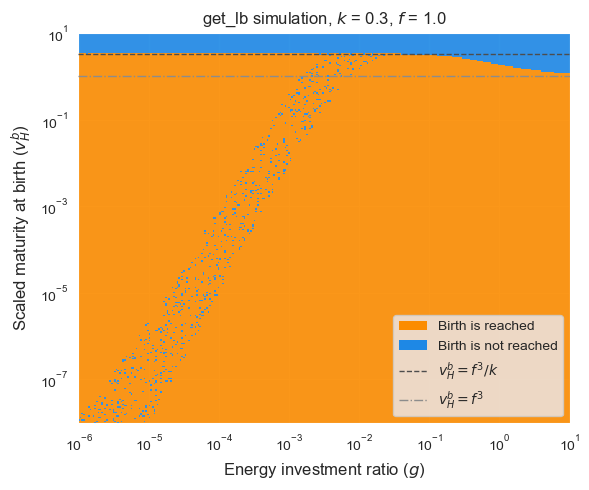

In [57]:
pos_color = "#FB8C00"
neg_color = "#1E88E5"
legend_loc = 'lower right'

fig, ax = plot_decision_mesh(df=df, decision_col='reached_birth', pos_color=pos_color, neg_color=neg_color, legend_loc=legend_loc)
ax.set_xlabel(f"Energy investment ratio ($g$)")
ax.set_ylabel(f"Scaled maturity at birth ($v_H^b$)")
ax.set_title(f"get_lb simulation, $k$ = {k:.1f}, $f$ = {f:.1f}")

# MAke a dot at (g, v_Hb) = (f, f^3/k)
# sns.scatterplot(data=disagree_df, x='g', y='v_Hb', color='red', marker='X', s=100, ax=ax)
# Add a straight line for v_hb = g
#ax.plot(df['g'], 3*10*df['g'], color='black', linestyle='--', label='$v_H^b = g$')

In [36]:
save_figure_in_formats(fig, outdir=save_figure_dir, filename=f"get_lb_simul_k_{k_fmt}_f_{f_fmt}", dpi=300, formats=['png', 'pdf'])

### Simulation with `get_lb2`

Text(0.5, 1.0, 'get_lb2 simulation, $k$ = 0.3, $f$ = 1.0')

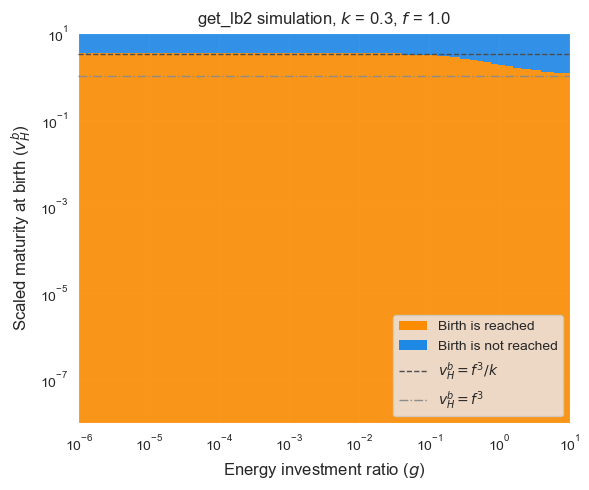

In [37]:
fig, ax = plot_decision_mesh(df=df, decision_col='reached_birth_get_lb2', pos_color=pos_color, neg_color=neg_color, legend_loc=legend_loc)
ax.set_xlabel(f"Energy investment ratio ($g$)")
ax.set_ylabel(f"Scaled maturity at birth ($v_H^b$)")
ax.set_title(f"get_lb2 simulation, $k$ = {k:.1f}, $f$ = {f:.1f}")


In [38]:
save_figure_in_formats(fig, outdir=save_figure_dir, filename=f"get_lb2_simul_k_{k_fmt}_f_{f_fmt}", dpi=300, formats=['png', 'pdf'])

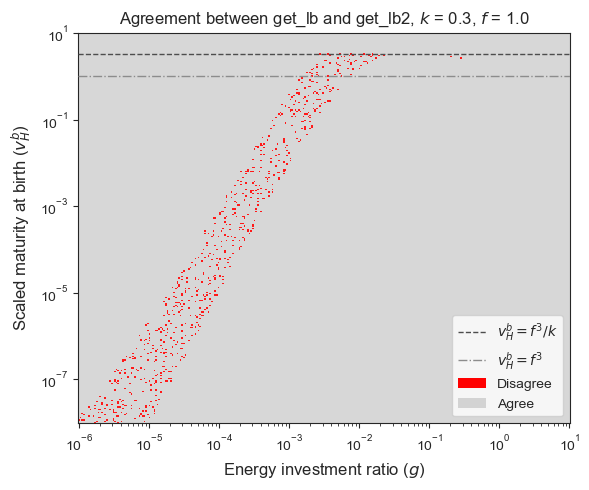

In [100]:
# Plot a heatmap of the disagreement between the two simulation methods
df['get_lb_disagree'] = df['reached_birth'] != df['reached_birth_get_lb2']
fig, ax = plot_decision_mesh(df=df, decision_col='get_lb_disagree', pos_color='red', neg_color='lightgray', legend_loc=legend_loc)

ax.set_xlabel(f"Energy investment ratio ($g$)")
ax.set_ylabel(f"Scaled maturity at birth ($v_H^b$)")

ax.set_title(f"Agreement between get_lb and get_lb2, $k$ = {k:.1f}, $f$ = {f:.1f}")

# Edit legend labels
base_handles, base_labels = ax.get_legend_handles_labels()
ax._region_legend_labels = ['Disagree', 'Agree']
handles = base_handles + ax._region_legend_handles
labels = base_labels + ax._region_legend_labels
ax.legend(handles, labels, loc=legend_loc)


In [123]:
df2['k*vHb-c'] = df2['k'] * df2['v_Hb'] - (df2['f'] * (df2['g'] + df2['lb']) / (df2['g'] + df2['f']) * df2['lb'] * df2['lb'])

df2[df['get_lb_disagree']]

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message,k*vHb-c
Row,,,,,,,,,,,,,,
11,0.000002,0.3,1.000000e-08,1,0.001444,2524.703167,1,1,True,1,0.576067,none,NaN,-1.186438e-11
25,0.000004,0.3,1.000000e-08,1,0.001445,1188.449906,1,1,True,1,0.574694,none,NaN,-2.523796e-11
312,0.000002,0.3,1.071767e-08,1,0.001477,2448.241660,1,1,True,1,0.053324,none,NaN,-1.311336e-11
317,0.000002,0.3,1.071767e-08,1,0.001478,1870.489846,1,1,True,1,0.096118,none,NaN,-1.717022e-11
323,0.000003,0.3,1.071767e-08,1,0.001478,1354.334181,1,1,True,1,0.104488,none,NaN,-2.372830e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85053,0.003618,0.3,3.299094e+00,1,0.996609,1038.804835,1,1,True,1,0.146131,none,NaN,-1.443855e-04
85060,0.005277,0.3,3.299094e+00,1,0.996655,712.484344,1,1,True,1,0.128498,none,NaN,-2.886159e-04
85067,0.007696,0.3,3.299094e+00,1,0.996736,488.738948,1,1,True,1,0.133344,none,NaN,-5.370495e-04


In [132]:
df.loc[11]['v_Hb']

np.float64(1e-08)

In [122]:
df[df['get_lb_disagree']]

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message,reached_birth_get_lb2,get_lb_disagree,execution_time_get_lb2,k*vHb-c
Row,,,,,,,,,,,,,,,,,
11,0.000002,0.3,1.000000e-08,1,0.001386,2424.513399,True,False,False,1,0.237751,none,NaN,True,True,0.576067,3.324387e-10
25,0.000004,0.3,1.000000e-08,1,0.001416,1164.720348,True,False,False,1,0.236772,none,NaN,True,True,0.574694,1.521857e-10
312,0.000002,0.3,1.071767e-08,1,0.001420,2353.779164,True,False,False,1,0.015511,none,NaN,True,True,0.053324,3.461082e-10
317,0.000002,0.3,1.071767e-08,1,0.001433,1813.971118,True,False,False,1,0.132952,none,NaN,True,True,0.096118,2.668562e-10
323,0.000003,0.3,1.071767e-08,1,0.001445,1323.878103,True,False,False,1,0.134971,none,NaN,True,True,0.104488,1.896970e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85053,0.003618,0.3,3.299094e+00,1,0.983086,1021.064569,True,False,False,1,0.071506,none,NaN,True,True,0.146131,3.955722e-02
85060,0.005277,0.3,3.299094e+00,1,0.987246,704.010522,True,False,False,1,0.073404,none,NaN,True,True,0.128498,2.743897e-02
85067,0.007696,0.3,3.299094e+00,1,0.990195,484.696506,True,False,False,1,0.053881,none,NaN,True,True,0.133344,1.878152e-02


In [124]:
df[df['get_lb_disagree'] & (df['k*vHb-c'] > 0)]


,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message,reached_birth_get_lb2,get_lb_disagree,execution_time_get_lb2,k*vHb-c
Row,,,,,,,,,,,,,,,,,
11,0.000002,0.3,1.000000e-08,1,0.001386,2424.513399,True,False,False,1,0.237751,none,NaN,True,True,0.576067,3.324387e-10
25,0.000004,0.3,1.000000e-08,1,0.001416,1164.720348,True,False,False,1,0.236772,none,NaN,True,True,0.574694,1.521857e-10
312,0.000002,0.3,1.071767e-08,1,0.001420,2353.779164,True,False,False,1,0.015511,none,NaN,True,True,0.053324,3.461082e-10
317,0.000002,0.3,1.071767e-08,1,0.001433,1813.971118,True,False,False,1,0.132952,none,NaN,True,True,0.096118,2.668562e-10
323,0.000003,0.3,1.071767e-08,1,0.001445,1323.878103,True,False,False,1,0.134971,none,NaN,True,True,0.104488,1.896970e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85053,0.003618,0.3,3.299094e+00,1,0.983086,1021.064569,True,False,False,1,0.071506,none,NaN,True,True,0.146131,3.955722e-02
85060,0.005277,0.3,3.299094e+00,1,0.987246,704.010522,True,False,False,1,0.073404,none,NaN,True,True,0.128498,2.743897e-02
85067,0.007696,0.3,3.299094e+00,1,0.990195,484.696506,True,False,False,1,0.053881,none,NaN,True,True,0.133344,1.878152e-02


In [93]:
log_g = np.log(df[df['get_lb_disagree'] & (df['g'] < 0.05)]['g'])
log_vHb = np.log(df[df['get_lb_disagree'] & (df['g'] < 0.05)]['v_Hb'])
from sklearn.linear_model import LinearRegression
reg = LinearRegression(fit_intercept=True).fit(log_g.values.reshape(-1, 1), log_vHb.values)
print(f"log(v_Hb) = {reg.coef_[0]:.2f} * log(g) + {reg.intercept_:.2f}")
print(f"v_Hb = g^{reg.coef_[0]:.2f} * exp({reg.intercept_:.2f})")
print("R^2:", reg.score(log_g.values.reshape(-1, 1), log_vHb.values))

log(v_Hb) = 2.49 * log(g) + 13.71
v_Hb = g^2.49 * exp(13.71)
R^2: 0.9446750314374025


In [104]:
reg.coef_[0], reg.intercept_

(np.float64(2.4923077101412847), np.float64(13.710427674556229))

In [112]:
import ipywidgets
from IPython.display import display

def plot_line_g_vhb(slope, intercept):
    fig, ax = plt.subplots()
    g_values = np.logspace(-6, 1, 100)
    vHb_values = np.exp(intercept) * g_values ** slope
    ax.plot(g_values, vHb_values, label=f"v_Hb = g^{slope:.2f} * exp({intercept:.2f})")
    ax.scatter(np.exp(log_g), np.exp(log_vHb), color='red', label='Disagree points', s=2)
    ax.axhline(1/0.3, color='black', linestyle='--')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energy investment ratio $g$')
    ax.set_ylabel('Scaled maturity at birth $v_H^b$')
    ax.legend()

slope_slider = ipywidgets.FloatSlider(value=reg.coef_[0], min=0, max=5, step=0.1, description='Slope')
intercept_slider = ipywidgets.FloatSlider(value=reg.intercept_, min=-10, max=30, step=0.1, description='Intercept')
ipywidgets.interact(plot_line_g_vhb, slope=slope_slider, intercept=intercept_slider)

interactive(children=(FloatSlider(value=2.4923077101412847, description='Slope', max=5.0), FloatSlider(value=1…

<function __main__.plot_line_g_vhb(slope, intercept)>

In [133]:
# Widgets to overlay a square over the disagreement points
def plot_line_g_vhb_with_square(g, v_Hb, square_size):
    fig, ax = plt.subplots()
    g_values = np.logspace(-6, 1, 100)
    vHb_values = np.exp(reg.intercept_) * g_values ** reg.coef_[0]
    ax.plot(g_values, vHb_values, label=f"v_Hb = g^{reg.coef_[0]:.2f} * exp({reg.intercept_:.2f})")
    ax.scatter(np.exp(log_g), np.exp(log_vHb), color='red', label='Disagree points', s=2)
    ax.axhline(1/0.3, color='black', linestyle='--')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energy investment ratio $g$')
    ax.set_ylabel('Scaled maturity at birth $v_H^b$')
    ax.legend()

    # Add square
    square = plt.Rectangle((g - square_size/2, v_Hb - square_size/2), square_size, square_size, fill=False, edgecolor='green', linewidth=2)
    ax.add_patch(square)
g_slider = ipywidgets.FloatLogSlider(value=0.01, base=10, min=-6, max=1, step=0.1, description='g')
v_Hb_slider = ipywidgets.FloatLogSlider(value=0.01, base=10, min=-6, max=1, step=0.1, description='v_Hb')
square_size_slider = ipywidgets.FloatLogSlider(value=0.01, base=10, min=-6, max=1, step=0.1, description='Square size')
ipywidgets.interact(plot_line_g_vhb_with_square, g=g_slider, v_Hb=v_Hb_slider, square_size=square_size_slider)

interactive(children=(FloatLogSlider(value=0.01, description='g', max=1.0, min=-6.0), FloatLogSlider(value=0.0…

<function __main__.plot_line_g_vhb_with_square(g, v_Hb, square_size)>

### Simulation time differences

In [76]:
df[['execution_time', 'execution_time_get_lb2']].describe()

,execution_time,execution_time_get_lb2
count,90000.000000,90000.000000
mean,0.073191,0.090036
std,0.087558,0.089512
min,0.007471,0.012808
25%,0.022516,0.040714
50%,0.032143,0.054911
75%,0.131576,0.137515
max,1.308261,1.171432


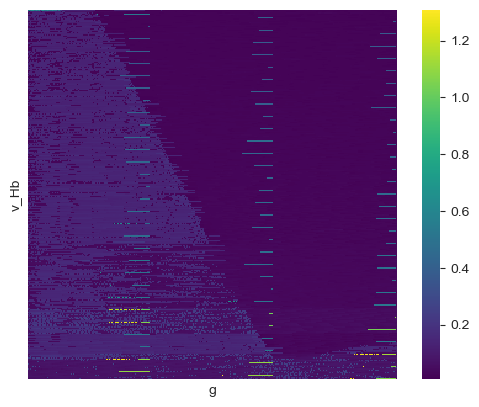

In [72]:
# heatmap of column 'execution_time' in seconds
ax = sns.heatmap(df.pivot(index='v_Hb', columns='g', values='execution_time'), cmap='viridis', xticklabels=False, yticklabels=False, square=True)

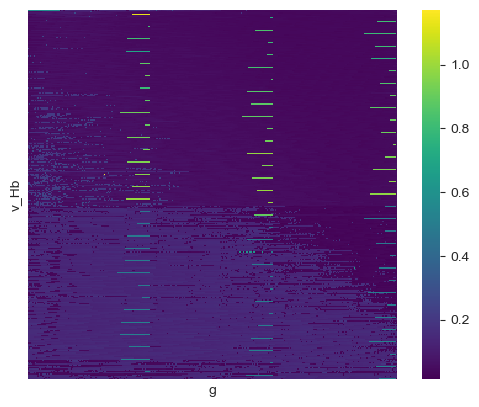

In [75]:
# heatmap of column 'execution_time' in seconds
ax = sns.heatmap(df.pivot(index='v_Hb', columns='g', values='execution_time_get_lb2'), cmap='viridis', xticklabels=False, yticklabels=False, square=True)

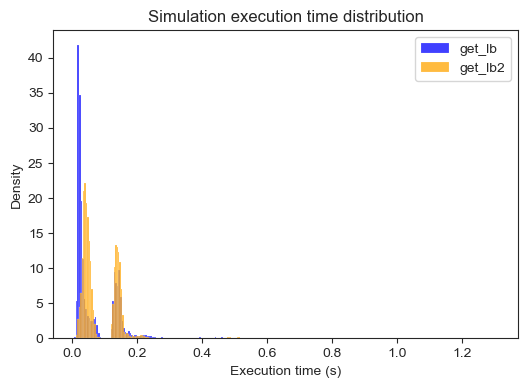

In [82]:
# Historgram of simulation time, overlaped
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df['execution_time'], color='blue', label='get_lb', kde=False, stat='density', ax=ax)
sns.histplot(df['execution_time_get_lb2'], color='orange', label='get_lb2', kde=False, stat='density', ax=ax)
ax.set_xlabel('Execution time (s)')
ax.set_ylabel('Density')
ax.set_title('Simulation execution time distribution')
ax.legend()

In [164]:
simul_filename = "grid_g_log_5em05_0p0002_N300_k_fixed_0p3_vHb_log_5em05_0p0002_N300_f_fixed_1_get_lb_tol1em10.csv"
df_zoom = pd.read_csv(simul_data_dir / simul_filename, index_col=0)
df_zoom['reached_birth'] = df_zoom['reached_birth'].astype(bool)


In [165]:
df_zoom['reached_birth'].value_counts()

reached_birth
True     82686
False     7314
Name: count, dtype: int64

(5e-05, 0.0002)

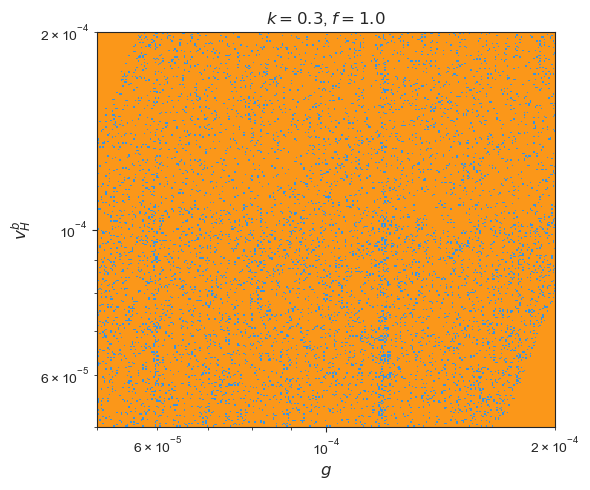

In [166]:
fig, ax = plot_decision_mesh(df_zoom, decision_col='reached_birth', pos_color=pos_color, neg_color=neg_color,)
# Remove legend
ax.legend_.remove()
ax.set_xlim([5e-5, 2e-4])
ax.set_ylim([5e-5, 2e-4])


In [160]:
df_zoom[~df_zoom['reached_birth']].loc[2886]

g                   0.000118
k                        0.3
v_Hb                0.000052
f                          1
lb                  0.024828
tb                634.851013
lb<f                       1
k*vHb<c                    0
reached_birth          False
success                    1
execution_time      0.118823
error_type              none
error_message            NaN
Name: 2886, dtype: object

<Axes: xlabel='g', ylabel='v_Hb'>

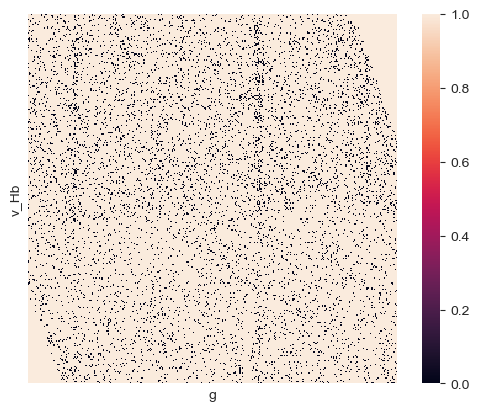

In [140]:
sns.heatmap(df_zoom.pivot(columns='v_Hb', index='g', values='reached_birth').T, xticklabels=False, yticklabels=False, square=True)

## Plot GP decision boundary

In [12]:
X = np.array([df['g'], df['k'], df['v_Hb'], df['f']]).T
gp_preds = gp.predict(X)
df['gp_pred'] = gp_preds

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': '$k=0.3$, $f=1.0$'}, xlabel='$g$', ylabel='$v_H^b$'>)

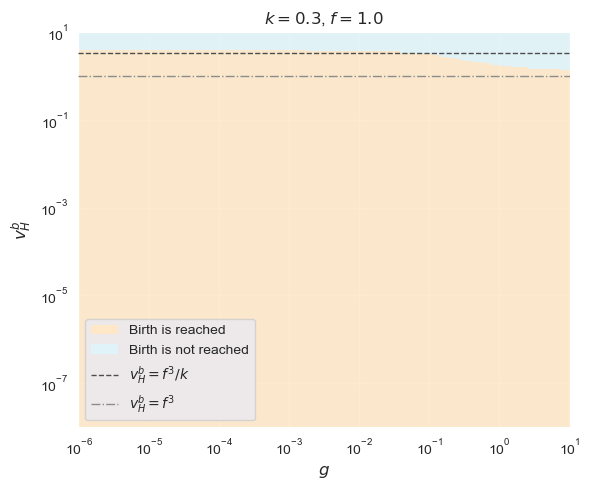

In [13]:
plot_decision_mesh(df=df, decision_col='gp_pred')

# Plot NN decision boundary

In [14]:
X = torch.tensor(np.array([df['g'], df['k'], df['v_Hb'], df['f']]).T, dtype=torch.float32)
X_scaled = scaler.transform(X)
net.eval()
df['nn_pred'] = net.predict(X_scaled)

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': '$k=0.3$, $f=1.0$'}, xlabel='$g$', ylabel='$v_H^b$'>)

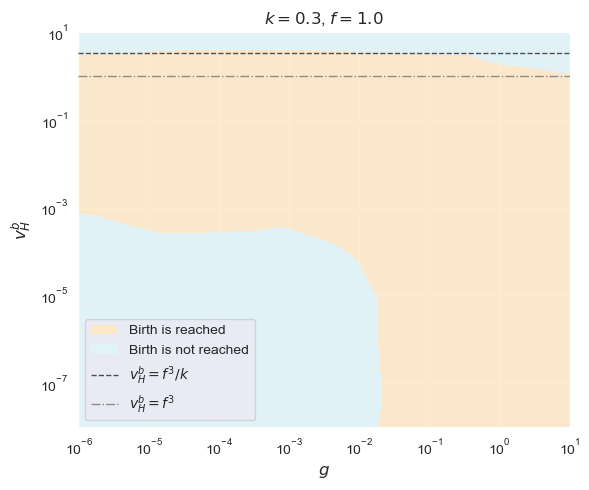

In [15]:
plot_decision_mesh(df=df, decision_col='nn_pred')

## Compare boundaries with simulation data

Text(0, 0.5, 'Scaled maturity at birth ($v_H^b$)')

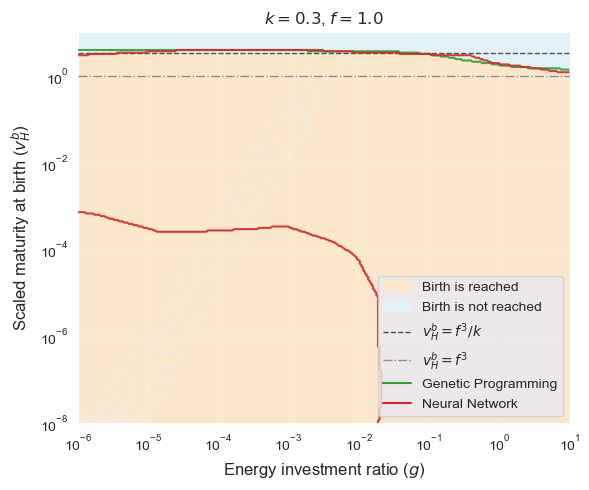

In [16]:
fig, ax = plot_decision_mesh_with_models(df=df, model_cols=['gp_pred', 'nn_pred'], decision_col='reached_birth', model_labels=['Genetic Programming', 'Neural Network'], model_colors=['tab:green', 'tab:red'], linewidth=1.5,
                                         legend_loc='lower right')

ax.set_xlabel(f"Energy investment ratio ($g$)")
ax.set_ylabel(f"Scaled maturity at birth ($v_H^b$)")
#ax.legend(loc='lower right')

In [17]:
if save_figures:
    save_figure_in_formats(fig, outdir=save_figure_dir, filename=f"boundary_compare_k_{k_fmt}_f_{f_fmt}", dpi=300, formats=['png', 'pdf'])

In [18]:
# f = 0.3
# k = 0.3
# if k > 1:
#     lower_bound = f ** 3 / k ** 3 / 10
#     upper_bound = f ** 3 / k * 10
#     print(f"{lower_bound:.3e} < v_Hb < {upper_bound:.3e}")
# elif k < 1:
#     lower_bound = f ** 3 / 10
#     upper_bound = f ** 3 / k * 10
#     print(f"{lower_bound:.3e} < v_Hb < {upper_bound:.3e}")


2.700e-03 < v_Hb < 9.000e-01
